# Credit Card Fraud Detection

In [2]:
# import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv(r"C:\Users\HP\Documents\Machine Learning Project\creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.274539e-12,-9.512736e-13,-4.398678e-13,-1.029671e-13,-3.838944e-13,7.529013e-13,-3.405412e-14,-1.660106e-13,1.027627e-13,...,-4.078958e-13,-9.849381e-13,-1.763859e-13,4.203004e-13,1.603967e-13,2.986665e-13,2.308042e-12,-2.239082e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Missing Value Check

In [7]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Dublicate Row Check

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1081


In [9]:
df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()).head(20)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [10]:
print(df["Class"].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [11]:
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


# EXPLORATORY DATA ANALYSIS

In [12]:
class_counts = df["Class"].value_counts()

print("Normal Transactions:", class_counts[0])
print("Fraud Transactions:", class_counts[1])

Normal Transactions: 284315
Fraud Transactions: 492


In [13]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


# Amount Distribution

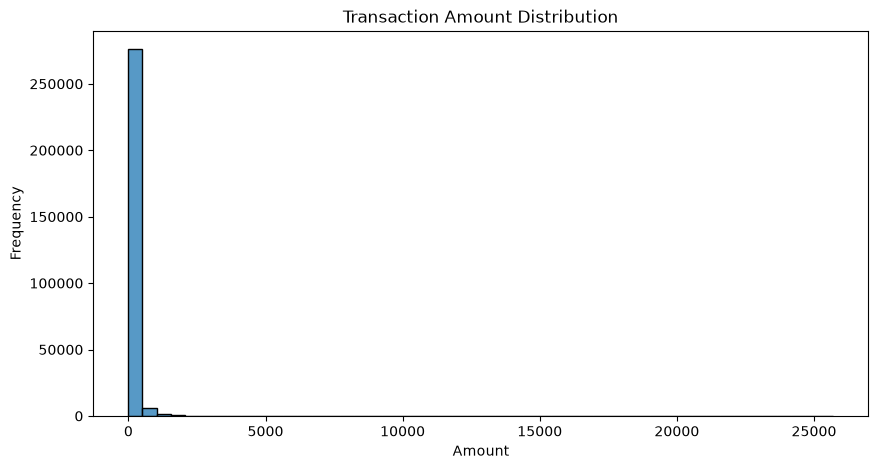

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Amount"], bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

# Normal vs Fraud Amount

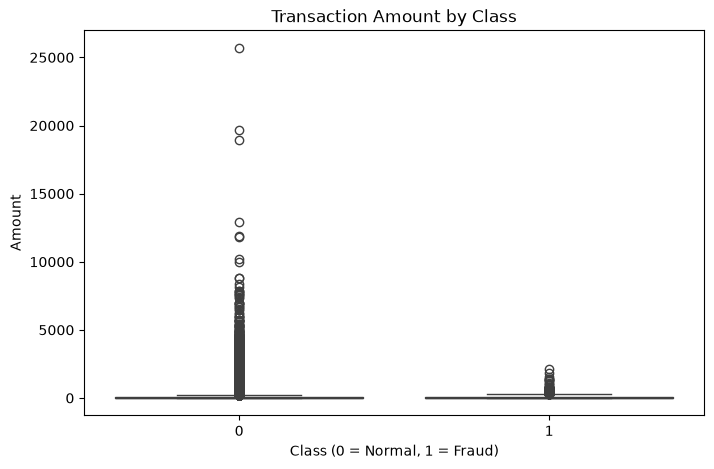

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

In [16]:
fraud_df = df[df["Class"] == 1]

fraud_df["Amount"].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

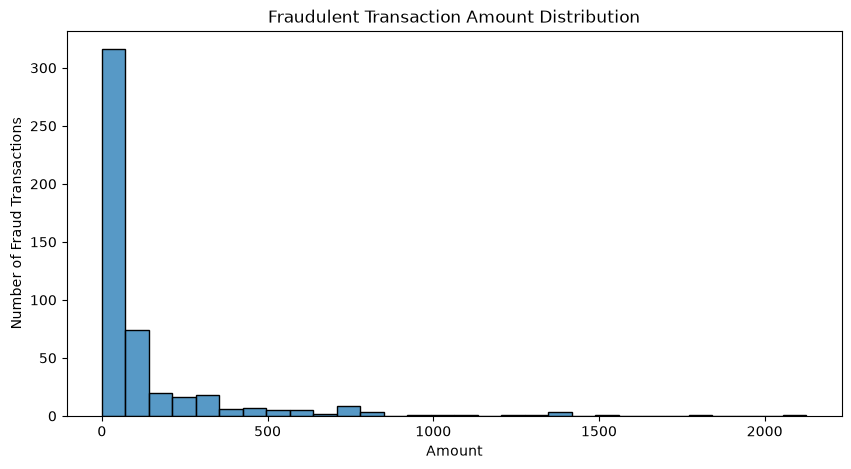

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(fraud_df["Amount"], bins=30)

plt.title("Fraudulent Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Number of Fraud Transactions")

plt.show()

In [18]:
print("Average Normal Transaction Amount:",
      df[df["Class"] == 0]["Amount"].mean())

print("Average Fraud Transaction Amount:",
      df[df["Class"] == 1]["Amount"].mean())

Average Normal Transaction Amount: 88.29102242231328
Average Fraud Transaction Amount: 122.21132113821139


In [19]:
print("Normal Transaction Time")
print(df[df["Class"] == 0]["Time"].describe())

print("\nFraud Transaction Time")
print(df[df["Class"] == 1]["Time"].describe())

Normal Transaction Time
count    284315.000000
mean      94838.202258
std       47484.015786
min           0.000000
25%       54230.000000
50%       84711.000000
75%      139333.000000
max      172792.000000
Name: Time, dtype: float64

Fraud Transaction Time
count       492.000000
mean      80746.806911
std       47835.365138
min         406.000000
25%       41241.500000
50%       75568.500000
75%      128483.000000
max      170348.000000
Name: Time, dtype: float64


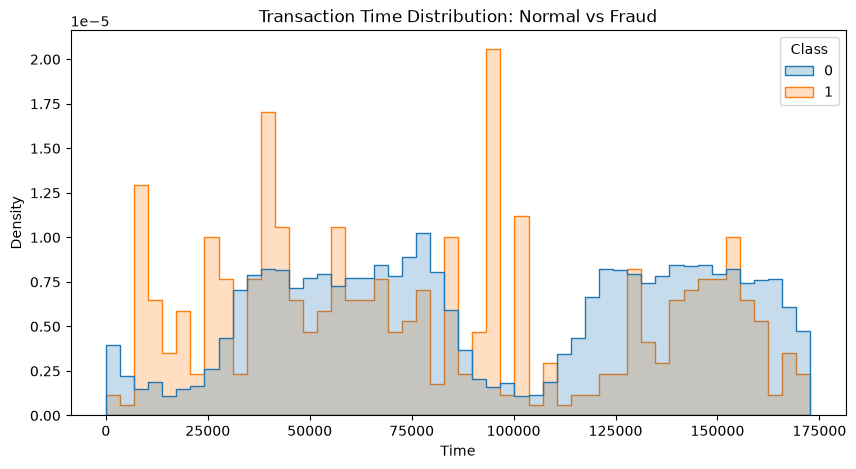

In [20]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution: Normal vs Fraud")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

In [21]:
corr = df.corr(numeric_only=True)["Class"].sort_values(ascending=False)

corr

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

In [22]:
corr.abs().sort_values(ascending=False).head(10)

Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
Name: Class, dtype: float64

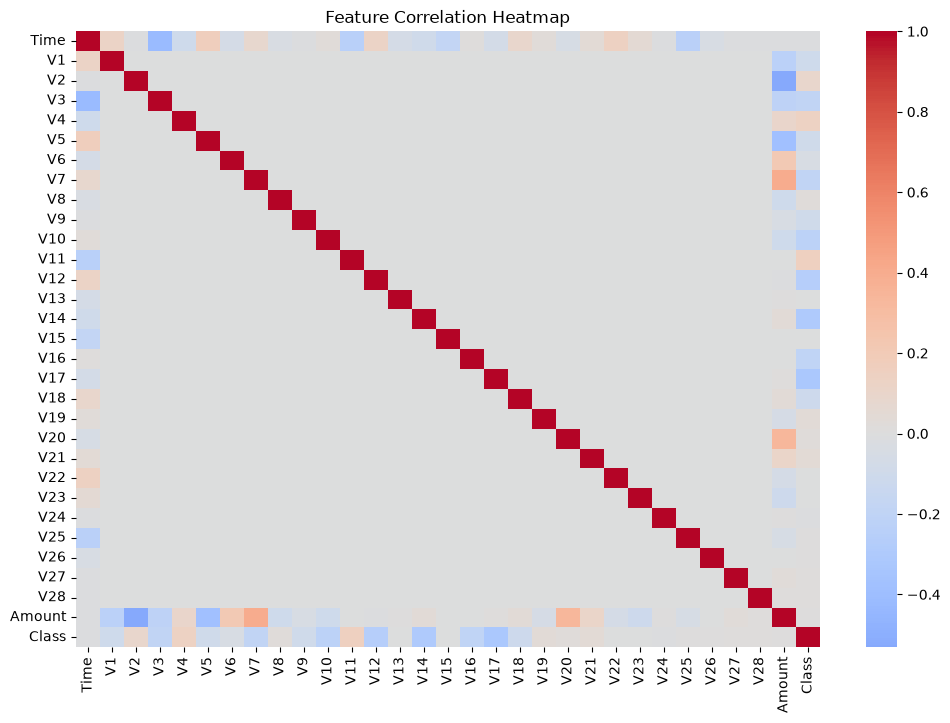

In [23]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.show()

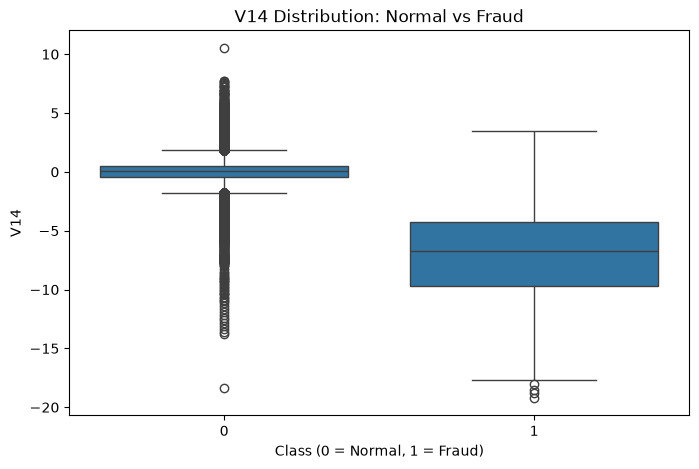

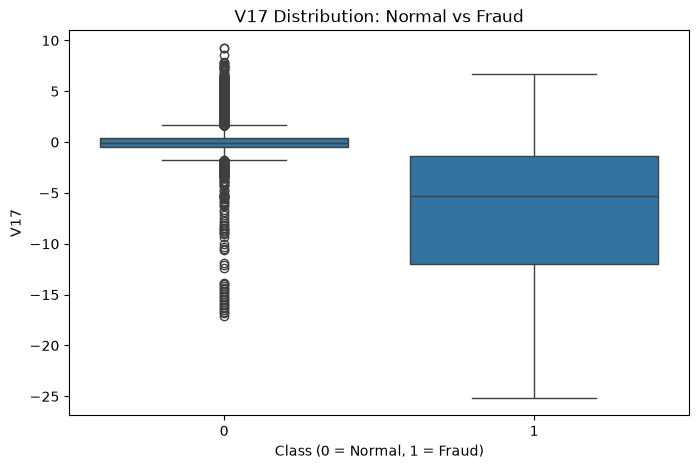

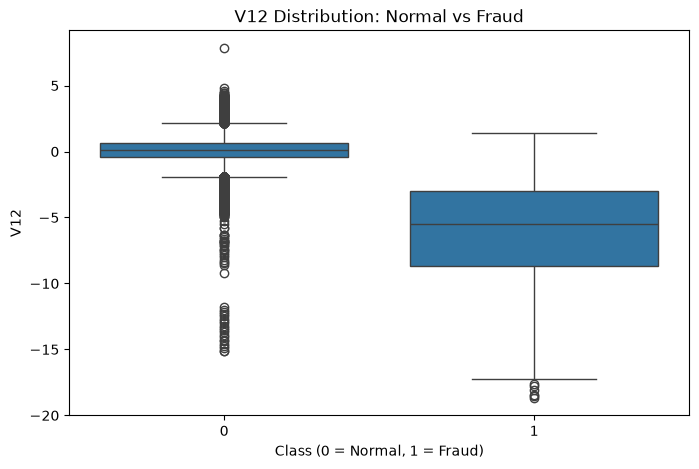

In [24]:
features = ["V14", "V17", "V12"]

for feature in features:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(x="Class", y=feature, data=df)
    
    plt.title(f"{feature} Distribution: Normal vs Fraud")
    plt.xlabel("Class (0 = Normal, 1 = Fraud)")
    plt.ylabel(feature)
    
    plt.show()

# Duplicate Handling

In [25]:
df_clean = df.drop_duplicates().copy()

print("Original Shape:", df.shape)
print("After Removing Duplicates:", df_clean.shape)

Original Shape: (284807, 31)
After Removing Duplicates: (283726, 31)


In [26]:
print(df_clean["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [27]:
print(df_clean["Class"].value_counts(normalize=True) * 100)

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


# Missing value

In [28]:
print("Missing Values:")
print(df_clean.isnull().sum())

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [29]:
print("Total Missing Values:", df_clean.isnull().sum().sum())

Total Missing Values: 0


In [30]:
print(df_clean.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


# Features and Target separate

In [31]:
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (283726, 30)
y Shape: (283726,)


#  Train/Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)


# Class Distribution

In [33]:
print("Training Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Class Distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing Class Distribution:
Class
0    56651
1       95
Name: count, dtype: int64


# Percentage

In [34]:
print("Training Percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training Percentage:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing Percentage:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


# Feature Scaling

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (226980, 30)
X_test_scaled shape: (56746, 30)


# Scalling Check

In [37]:
print("Training Mean:", X_train_scaled.mean())
print("Training Standard Deviation:", X_train_scaled.std())

Training Mean: -2.1412072925363843e-18
Training Standard Deviation: 1.0


# Baseline Model

In [38]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

baseline_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [39]:
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Evaluation

In [40]:
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline))
print("Recall:", recall_score(y_test, y_pred_baseline))
print("F1 Score:", f1_score(y_test, y_pred_baseline))

Accuracy: 0.9991188806259472
Precision: 0.8461538461538461
Recall: 0.5789473684210527
F1 Score: 0.6875


In [41]:
print(classification_report(y_test, y_pred_baseline))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



In [42]:
cm = confusion_matrix(y_test, y_pred_baseline)

print(cm)

[[56641    10]
 [   40    55]]


# Class-Weighted Logistic Regression

In [43]:
class_weight="balanced"

In [44]:
weighted_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

weighted_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [45]:
# Prediction
y_pred_weighted = weighted_model.predict(X_test_scaled)

In [46]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("Precision:", precision_score(y_test, y_pred_weighted))
print("Recall:", recall_score(y_test, y_pred_weighted))
print("F1 Score:", f1_score(y_test, y_pred_weighted))

Accuracy: 0.9753110351390406
Precision: 0.05638586956521739
Recall: 0.8736842105263158
F1 Score: 0.10593490746649649


In [47]:
print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746



# Confusion Metrics

In [48]:
cm_weighted = confusion_matrix(y_test, y_pred_weighted)

print(cm_weighted)

[[55262  1389]
 [   12    83]]


# SMOTE

In [49]:
from imblearn.over_sampling import SMOTE

print("SMOTE imported successfully!")

SMOTE imported successfully!


In [50]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


# SMOTE Logistic Regression

In [51]:
smote_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

smote_model.fit(X_train_smote, y_train_smote)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [52]:
y_pred_smote = smote_model.predict(X_test_scaled)

In [ ]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_smote))
print("Precision:", precision_score(y_test, y_pred_smote))
print("Recall:", recall_score(y_test, y_pred_smote))
print("F1 Score:", f1_score(y_test, y_pred_smote))

Accuracy: 0.9736721531033025
Precision: 0.053035143769968054
Recall: 0.8736842105263158
F1 Score: 0.1


In [54]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



In [55]:
# Confusion Metrics
cm_smote = confusion_matrix(y_test, y_pred_smote)

print(cm_smote)

[[55169  1482]
 [   12    83]]


# Random Forest

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\HP\AppData

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [57]:
# Prediction
y_pred_rf = rf_model.predict(X_test)

In [58]:
# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

Accuracy: 0.9994713283755683
Precision: 0.9452054794520548
Recall: 0.7263157894736842
F1 Score: 0.8214285714285714


In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [60]:
# confusion Metrics
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[56647     4]
 [   26    69]]


In [61]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(15))

V14    0.188663
V10    0.117722
V12    0.102422
V17    0.097098
V4     0.093188
V3     0.066788
V11    0.053492
V16    0.044913
V2     0.036496
V9     0.025199
V7     0.015847
V21    0.014432
V18    0.013045
V19    0.012057
V8     0.011725
dtype: float64


# Random Forest ki probability predictions

In [62]:
from sklearn.metrics import roc_auc_score, average_precision_score

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob_rf)
pr_auc = average_precision_score(y_test, y_prob_rf)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9391009960338881
PR-AUC: 0.8011957643870846


# Threshold Tuning

In [63]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold, zero_division=0)
    recall = recall_score(y_test, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test, y_pred_threshold, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )

Threshold: 0.10 | Precision: 0.7156 | Recall: 0.8211 | F1: 0.7647
Threshold: 0.20 | Precision: 0.8652 | Recall: 0.8105 | F1: 0.8370
Threshold: 0.30 | Precision: 0.9125 | Recall: 0.7684 | F1: 0.8343
Threshold: 0.40 | Precision: 0.9333 | Recall: 0.7368 | F1: 0.8235
Threshold: 0.50 | Precision: 0.9452 | Recall: 0.7263 | F1: 0.8214
Threshold: 0.60 | Precision: 0.9583 | Recall: 0.7263 | F1: 0.8263
Threshold: 0.70 | Precision: 0.9853 | Recall: 0.7053 | F1: 0.8221
Threshold: 0.80 | Precision: 0.9841 | Recall: 0.6526 | F1: 0.7848
Threshold: 0.90 | Precision: 0.9808 | Recall: 0.5368 | F1: 0.6939


# Final confusion matrix  threshold 0.20



In [64]:
final_threshold = 0.20

y_pred_final = (y_prob_rf >= final_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall:", recall_score(y_test, y_pred_final))
print("F1 Score:", f1_score(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

Accuracy: 0.9994713283755683
Precision: 0.8651685393258427
Recall: 0.8105263157894737
F1 Score: 0.8369565217391305

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.81      0.84        95

    accuracy                           1.00     56746
   macro avg       0.93      0.91      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56639    12]
 [   18    77]]


# Final Model Evaluation Visualizations

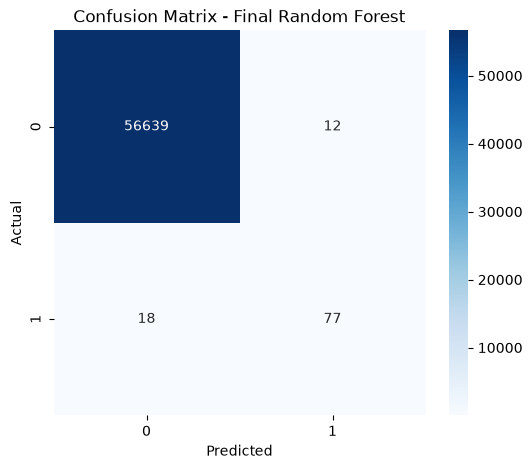

In [65]:
# Confusion Metrics
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, y_pred_final),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Final Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC Curve

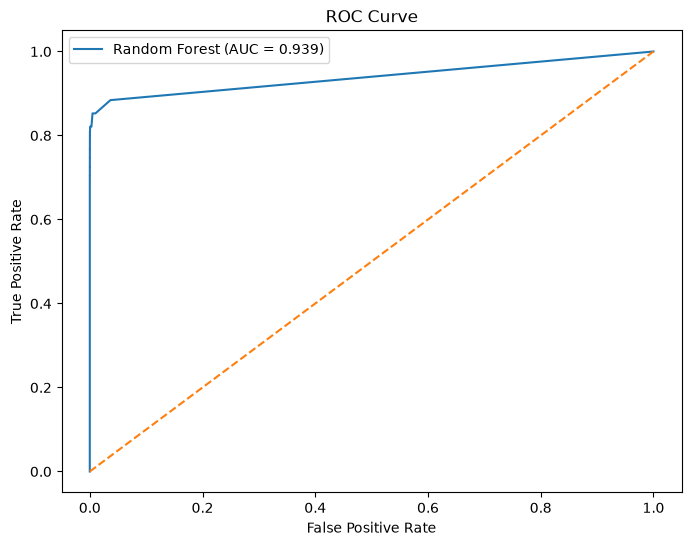

In [66]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

# Precision-Recall Curve

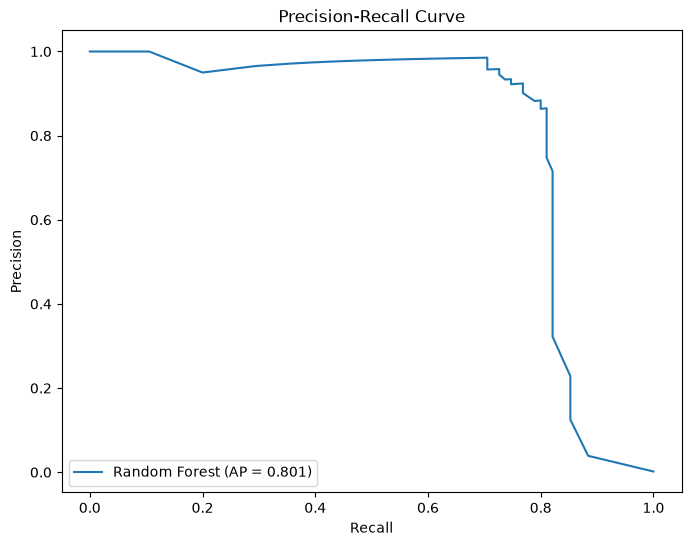

In [67]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"Random Forest (AP = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.show()

# Feature Importance Visualization

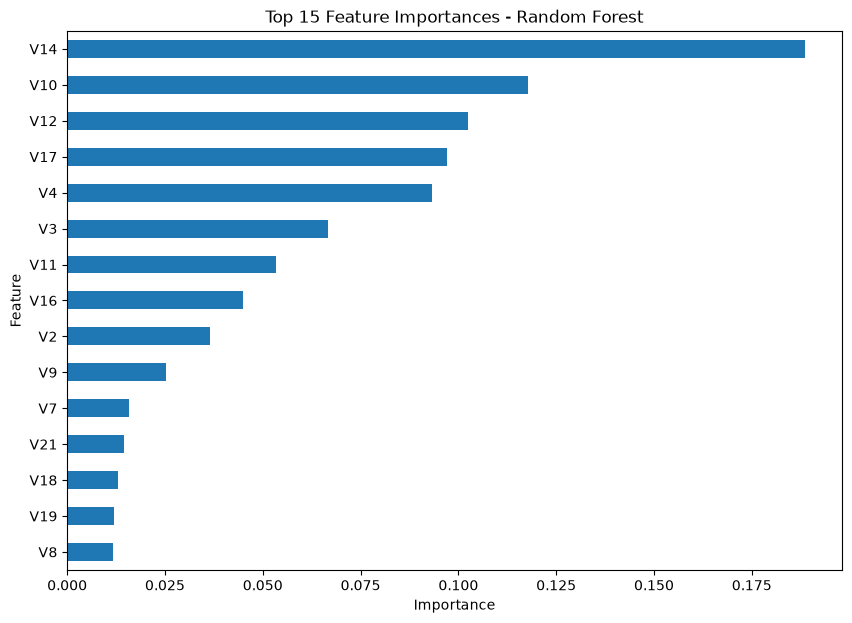

In [68]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

top_features.sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [70]:
import joblib
from pathlib import Path

# Create models folder if it doesn't exist
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save Random Forest model
model_path = models_dir / "fraud_detection_random_forest.pkl"
joblib.dump(rf_model, model_path)

# Save scaler
scaler_path = models_dir / "scaler.pkl"
joblib.dump(scaler, scaler_path)

# Save final threshold
threshold_path = models_dir / "threshold.pkl"
joblib.dump(final_threshold, threshold_path)

print("All files saved successfully!")
print("Model:", model_path)
print("Scaler:", scaler_path)
print("Threshold:", threshold_path)

All files saved successfully!
Model: ..\models\fraud_detection_random_forest.pkl
Scaler: ..\models\scaler.pkl
Threshold: ..\models\threshold.pkl


In [71]:
import joblib
from pathlib import Path

models_dir = Path("../models")

loaded_model = joblib.load(
    models_dir / "fraud_detection_random_forest.pkl"
)

loaded_scaler = joblib.load(
    models_dir / "scaler.pkl"
)

loaded_threshold = joblib.load(
    models_dir / "threshold.pkl"
)

print("Model loaded successfully!")
print("Threshold:", loaded_threshold)

Model loaded successfully!
Threshold: 0.2


# Prediction function

In [73]:
def predict_fraud(transaction_data):
    transaction_df = pd.DataFrame(
        [transaction_data],
        columns=X.columns
    )

    fraud_probability = loaded_model.predict_proba(
        transaction_df
    )[:, 1][0]

    prediction = int(fraud_probability >= loaded_threshold)

    result = (
        "Fraudulent Transaction"
        if prediction == 1
        else "Normal Transaction"
    )

    return {
        "prediction": prediction,
        "result": result,
        "fraud_probability": fraud_probability
    }

# Real test transaction

In [74]:
normal_transaction = X_test[y_test == 0].iloc[0].to_dict()
fraud_transaction = X_test[y_test == 1].iloc[0].to_dict()

In [75]:
predict_fraud(normal_transaction)

{'prediction': 0,
 'result': 'Normal Transaction',
 'fraud_probability': np.float64(0.0)}

In [76]:
# Fraud
predict_fraud(fraud_transaction)

{'prediction': 1,
 'result': 'Fraudulent Transaction',
 'fraud_probability': np.float64(0.91)}

# Final Model Comparison Table

In [77]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Class Weight)",
        "Logistic Regression (SMOTE)",
        "Random Forest"
    ],
    "Accuracy": [
        0.9991188806,
        0.9753110351,
        0.9736721531,
        0.9994713284
    ],
    "Precision": [
        0.8461538462,
        0.0563858696,
        0.0530351438,
        0.8651685393
    ],
    "Recall": [
        0.5789473684,
        0.8736842105,
        0.8736842105,
        0.8105263158
    ],
    "F1 Score": [
        0.6875,
        0.1059349075,
        0.1000,
        0.8369565217
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.999119,0.846154,0.578947,0.687500
1,Logistic Regression (Class Weight),0.975311,0.056386,0.873684,0.105935
2,Logistic Regression (SMOTE),0.973672,0.053035,0.873684,0.100000
3,Random Forest,0.999471,0.865169,0.810526,0.836957


In [78]:
from pathlib import Path
import joblib

models_dir = Path(r"C:\Users\HP\Documents\Machine Learning Project\models")

joblib.dump(
    rf_model,
    models_dir / "fraud_detection_random_forest.pkl"
)

joblib.dump(
    final_threshold,
    models_dir / "threshold.pkl"
)

print("Model and threshold saved successfully!")

Model and threshold saved successfully!


In [79]:
print((models_dir / "fraud_detection_random_forest.pkl").exists())
print((models_dir / "threshold.pkl").exists())

True
True


In [80]:
# One normal transaction
normal_sample = X_test[y_test == 0].iloc[0]

print(normal_sample)

Time      61290.000000
V1            1.228821
V2           -0.063408
V3            0.274145
V4            0.647465
V5           -0.048135
V6            0.372073
V7           -0.224231
V8            0.079939
V9            0.640759
V10          -0.273054
V11          -1.252728
V12           0.465079
V13           0.400502
V14          -0.292842
V15          -0.101774
V16          -0.399836
V17           0.034336
V18          -0.783550
V19           0.141345
V20          -0.096566
V21          -0.129554
V22          -0.083779
V23          -0.151661
V24          -0.700372
V25           0.598550
V26           0.491409
V27           0.002989
V28           0.001782
Amount       11.500000
Name: 86568, dtype: float64


In [81]:
# One fraud transaction
fraud_sample = X_test[y_test == 1].iloc[0]

print(fraud_sample)

Time      74159.000000
V1           -1.548788
V2            1.808698
V3           -0.953509
V4            2.213085
V5           -2.015728
V6           -0.913457
V7           -2.356013
V8            1.197169
V9           -1.678374
V10          -3.538650
V11           3.102090
V12          -3.993373
V13          -1.937411
V14          -3.822894
V15           0.830970
V16          -2.475359
V17          -5.211875
V18          -0.413872
V19           0.933262
V20           0.390786
V21           0.855138
V22           0.774745
V23           0.059037
V24           0.343200
V25          -0.468938
V26          -0.278338
V27           0.625922
V28           0.395573
Amount       76.940000
Name: 116139, dtype: float64


In [82]:
fraud_sample = X_test[y_test == 1].iloc[0]

print(fraud_sample)

Time      74159.000000
V1           -1.548788
V2            1.808698
V3           -0.953509
V4            2.213085
V5           -2.015728
V6           -0.913457
V7           -2.356013
V8            1.197169
V9           -1.678374
V10          -3.538650
V11           3.102090
V12          -3.993373
V13          -1.937411
V14          -3.822894
V15           0.830970
V16          -2.475359
V17          -5.211875
V18          -0.413872
V19           0.933262
V20           0.390786
V21           0.855138
V22           0.774745
V23           0.059037
V24           0.343200
V25          -0.468938
V26          -0.278338
V27           0.625922
V28           0.395573
Amount       76.940000
Name: 116139, dtype: float64
